In [1]:
from functools import namedtuple
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.text import TextPath
import subprocess
import warnings

from dti.utils import Method

In [2]:
def plot_results(
    d: pd.DataFrame,
    methods=[
        "ic50",
        "ic50corr",
        "allpairs",
        "pairs",
        "ic50allsets",
        "ic50sets",
        "allsets",
        "sets",
        "hodge",
    ],
):
    d = d[d["method"].isin(methods)]
    n_ds = d["dataset"].nunique()
    fig, axes = plt.subplots(1, n_ds, figsize=(3.5 * n_ds, 5), sharey=False)
    colors = dict(zip(methods, sns.color_palette()))

    if d["dataset"].nunique() == 1:
        axes = [axes]

    identity = lambda x: x
    transform = inv_transform = identity
    transform, inv_transform = np.atanh, np.tanh

    for ax, dataset in zip(axes, ["atcc", "ovcar", "kinodata", "landrum", "omnivore"]):
        df = d[d["dataset"] == dataset]
        for fold, group in df.groupby("fold"):
            group = group.set_index("method").reindex(methods).dropna().reset_index()
            ax.plot(
                group["method"],
                transform(group["corr"]),
                linestyle="-",
                color="gray",
                alpha=0.5,
                zorder=0,
            )

        for method in methods:
            subset = df[(df["method"] == method) & (df["status"] == "Running")]
            if len(subset) > 0:
                ax.scatter(
                    subset["method"],
                    transform(subset["corr"]),
                    s=100,
                    label=method,
                    color=colors[method],
                    edgecolors="black",
                    marker="^",
                )
            subset = df[(df["method"] == method) & (df["status"] == "Finished")]
            if len(subset) > 0:
                ax.scatter(
                    subset["method"],
                    transform(subset["corr"]),
                    s=100,
                    label=method,
                    color=colors[method],
                    edgecolors="black",
                    marker="o",
                )
        sns.boxplot(
            df,
            x="method",
            y=transform(df["corr"]),
            hue="method",
            palette=colors,
            ax=ax,
            zorder=0,
            width=0.3,
            whis=10000,
        )

        ms = [str(Method.from_string(m)) for m in methods if m in df["method"].unique()]

        ax.set_title(f"dataset: {dataset}")
        ax.set_ylabel(None)
        ax.set_xlabel("method")
        ax.set_xticks(range(len(ms)))
        ax.set_xticklabels(ms, rotation=90)
        ax.set_xlim(-0.5, len(ms) - 0.5)
        sns.despine(ax=ax, left=False, bottom=True)

    axes[0].set_ylabel("aggregate correlation")
    plt.tight_layout()
    plt.show()

In [3]:
res = subprocess.run(["./scripts/status.sh"], cwd="..", capture_output=True)

Row = namedtuple("Row", "ident dataset method epoch fold corr status".split())
data_line = (
    lambda line: "Ident" not in line
    and "―" not in line
    and "━" not in line
    and line != ""
)


def parse_row(line: str) -> Row:
    if not data_line(line):
        return None
    try:
        return Row(*line.split())
    except:
        return None


d = pd.DataFrame(
    [r for r in map(parse_row, res.stdout.decode().split("\n")) if r is not None]
)
d = d.astype({"corr": float, "fold": int})
d.head()

,ident,dataset,method,epoch,fold,corr,status
0,bc50,atcc,allpairs,61,0,0.6893,Finished
1,4edd,atcc,allsets,94,0,0.6970,Finished
2,4987,atcc,hodge,691,0,0.4060,Finished
3,4e4b,atcc,ic50,502,0,0.6790,Finished
4,ef69,atcc,ic50allsets,168,0,0.7169,Finished


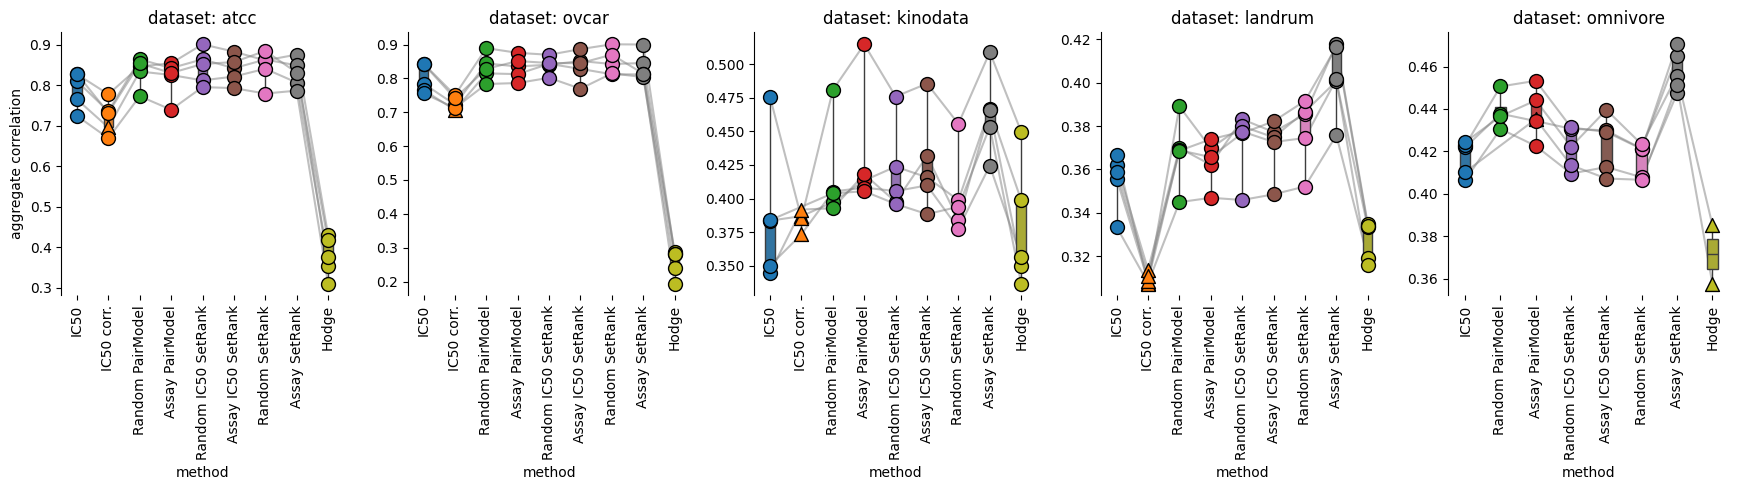

In [4]:
plot_results(d)

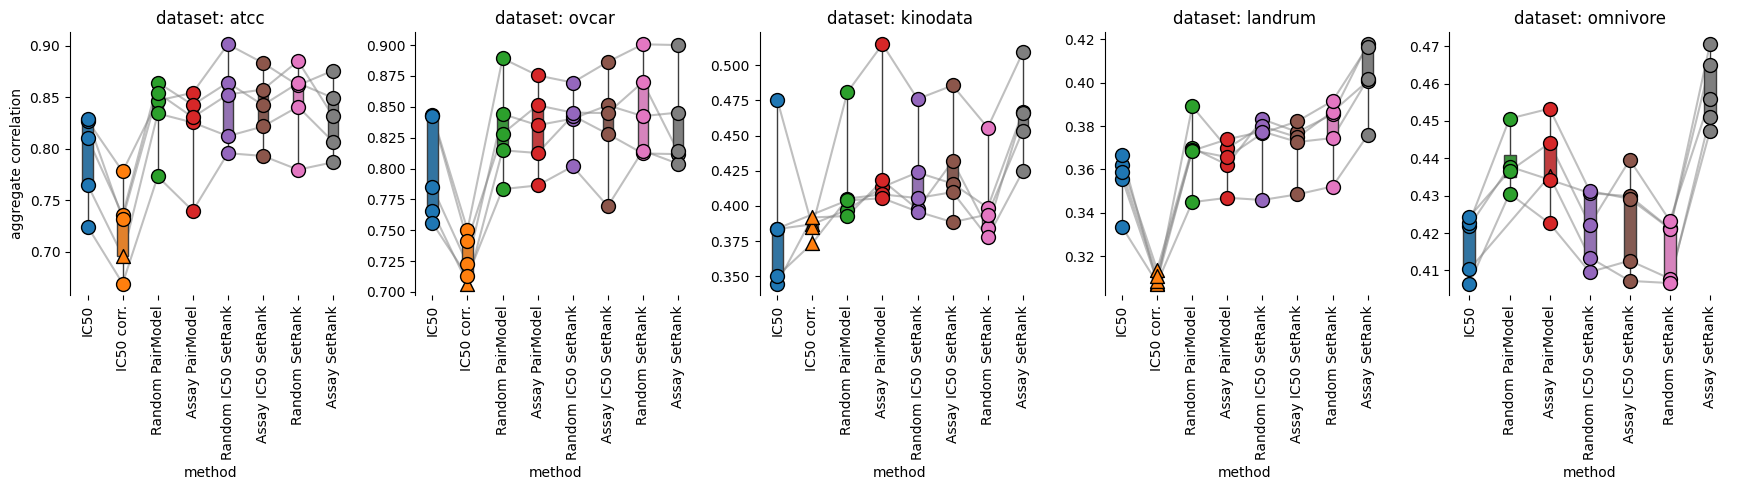

In [5]:
plot_results(d[d["method"] != "hodge"])

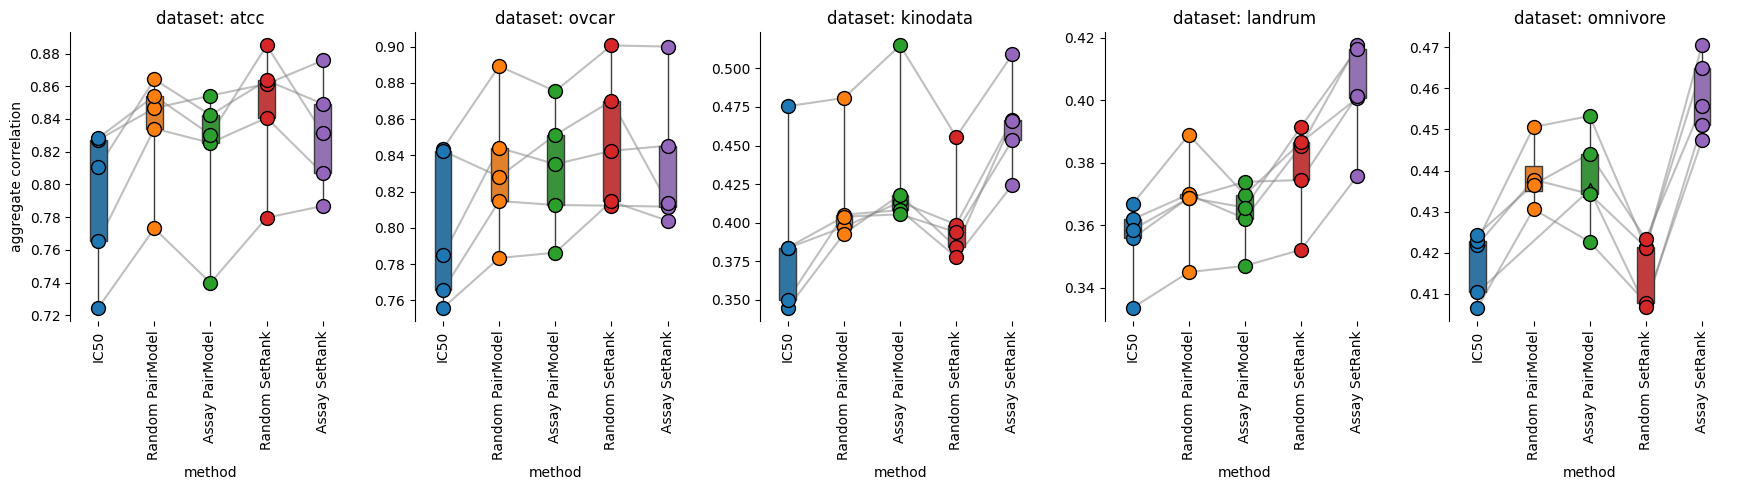

In [6]:
plot_results(d, ["ic50", "allpairs", "pairs", "allsets", "sets"])

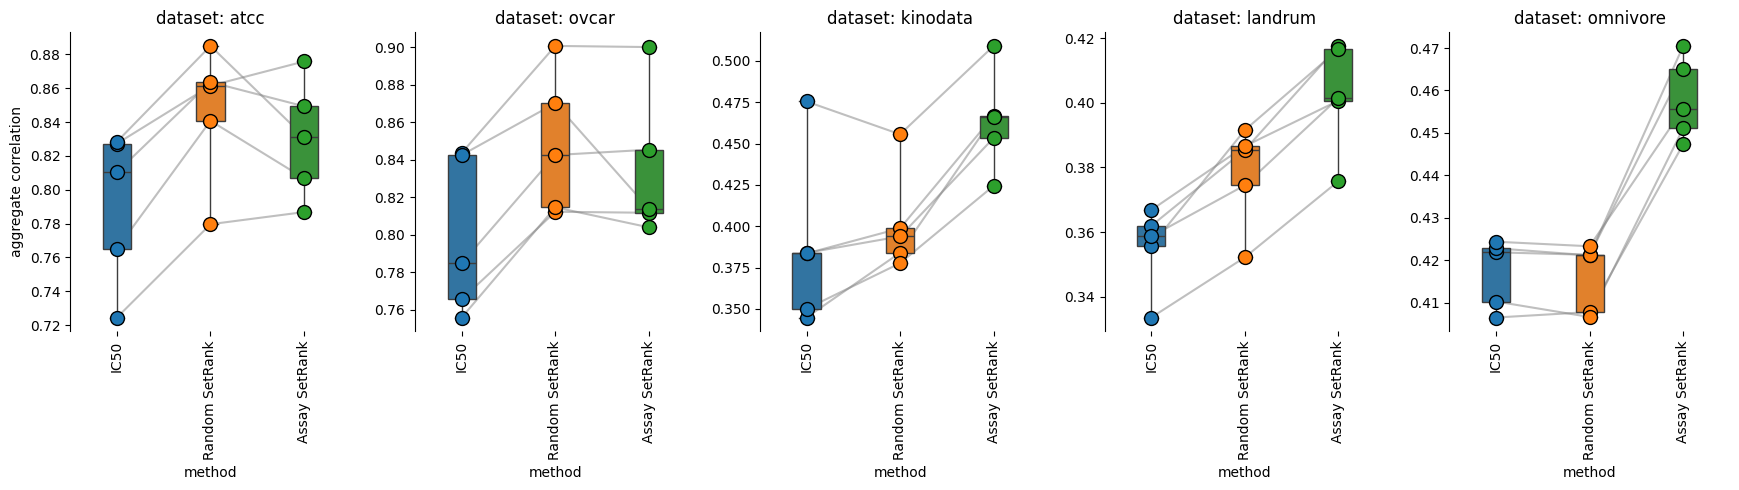

In [7]:
plot_results(d, ["ic50", "allsets", "sets"])